# Tugas Lab 2: CountVectorizer vs TF-IDF dengan stop words

Sumber: [modul Polinema](https://polinema.gitbook.io/jti-modul-praktikum-pembelajaran-mesin-mah/js05-klasifikasi-1/tugas-lab-2).

Jalankan sel secara berurutan. Dataset tersedia lokal di `dataset/`. Semua hasil di bawah berasal dari eksekusi kode.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

ROOT = Path.cwd() if (Path.cwd() / 'dataset').exists() else Path.cwd() / 'JS05'
DATA = ROOT / 'dataset'

def evaluate(model, X_train, X_test, y_train, y_test, title):
    pred = model.predict(X_test)
    print(title)
    print(f'Akurasi train: {model.score(X_train, y_train):.4f}')
    print(f'Akurasi test : {accuracy_score(y_test, pred):.4f}')
    print(classification_report(y_test, pred, zero_division=0))
    ConfusionMatrixDisplay.from_predictions(y_test, pred)
    plt.title(title)
    plt.show()
    return pred


## 1. Data dan split yang sama dengan Lab 3
Dipakai stop words bahasa Inggris karena SMS pada dataset berbahasa Inggris. Butir perbandingan ditafsirkan sebagai perbandingan dua metode pada tugas ini.

In [2]:
df = pd.read_csv(DATA / 'spam.csv', encoding='latin-1')
print(df.head().to_string())
df = df.iloc[:, :2].rename(columns={'v1': 'Labels', 'v2': 'SMS'})
print(df['Labels'].value_counts())
df.info()
print(df.describe().to_string())
assert not df.isna().any().any()
df['Labels'] = df['Labels'].map({'ham': 0, 'spam': 1})
X_train, X_test, y_train, y_test = train_test_split(
    df['SMS'], df['Labels'], test_size=0.2, random_state=50)


     v1                                                                                                                                                           v2 Unnamed: 2 Unnamed: 3 Unnamed: 4
0   ham                                              Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...        NaN        NaN        NaN
1   ham                                                                                                                                Ok lar... Joking wif u oni...        NaN        NaN        NaN
2  spam  Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's        NaN        NaN        NaN
3   ham                                                                                                            U dun say so early hor... U c already then say...        NaN        NaN        NaN
4   ham   

## 2. Dua model dan evaluasi
Kedua vocabulary dan bobot IDF hanya dipelajari dari data latih. Akurasi, precision, recall, dan F1 untuk spam dilaporkan karena kelas ham lebih banyak.

CountVectorizer + stop words
Akurasi train: 0.9946
Akurasi test : 0.9830
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       954
           1       0.98      0.90      0.94       161

    accuracy                           0.98      1115
   macro avg       0.98      0.95      0.96      1115
weighted avg       0.98      0.98      0.98      1115

TF-IDF + stop words
Akurasi train: 0.9843
Akurasi test : 0.9605
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       954
           1       1.00      0.73      0.84       161

    accuracy                           0.96      1115
   macro avg       0.98      0.86      0.91      1115
weighted avg       0.96      0.96      0.96      1115

          fitur  akurasi_train  akurasi_test  precision_spam  recall_spam  f1_spam
CountVectorizer       0.994615      0.982960         0.97973     0.900621 0.938511
         TF-IDF       0.984294      0.96053

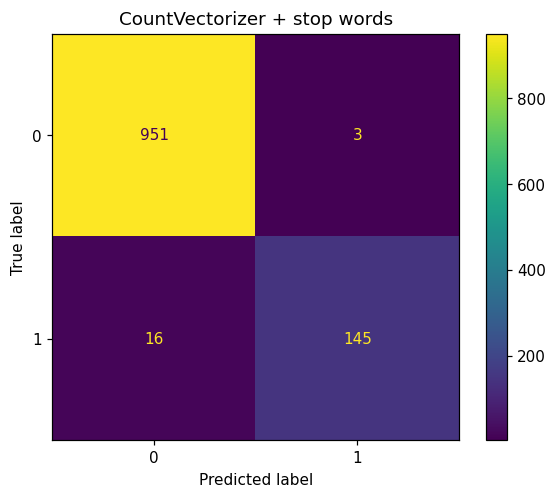

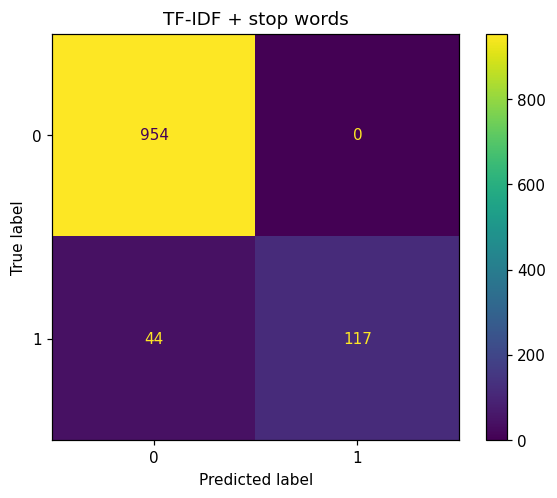

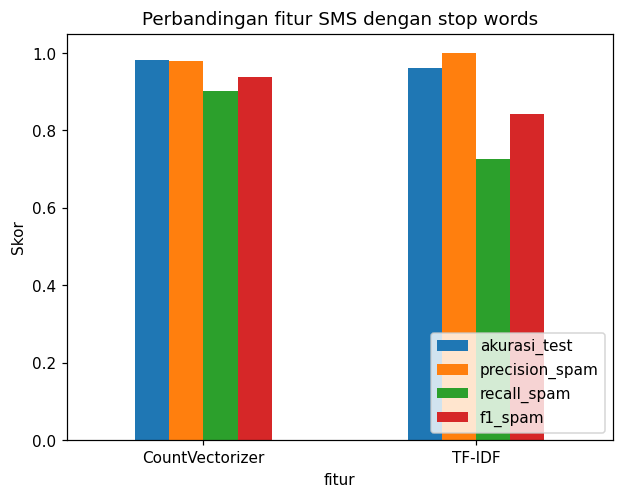

In [3]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import precision_score, recall_score, f1_score
rows = []
for name, vectorizer in [('CountVectorizer', CountVectorizer(stop_words='english')),
                         ('TF-IDF', TfidfVectorizer(stop_words='english'))]:
    model = Pipeline([('vectorizer', vectorizer), ('nb', MultinomialNB())])
    model.fit(X_train, y_train)
    pred = evaluate(model, X_train, X_test, y_train, y_test, name + ' + stop words')
    rows.append({'fitur': name, 'akurasi_train': model.score(X_train, y_train),
        'akurasi_test': accuracy_score(y_test, pred), 'precision_spam': precision_score(y_test, pred),
        'recall_spam': recall_score(y_test, pred), 'f1_spam': f1_score(y_test, pred)})
comparison = pd.DataFrame(rows)
print(comparison.to_string(index=False))
comparison.to_csv(ROOT / 'hasil_sms_perbandingan.csv', index=False)
comparison.set_index('fitur')[['akurasi_test', 'precision_spam', 'recall_spam', 'f1_spam']].plot.bar(rot=0, ylim=(0, 1.05))
plt.ylabel('Skor')
plt.title('Perbandingan fitur SMS dengan stop words')
plt.legend(loc='lower right')
plt.show()
best = comparison.sort_values(['f1_spam', 'akurasi_test'], ascending=False).iloc[0]
print(f"Kesimpulan: {best['fitur']} terbaik pada split ini berdasarkan F1 spam ({best['f1_spam']:.4f}), dengan akurasi {best['akurasi_test']:.4f}.")
print('F1 dipakai untuk menyeimbangkan precision dan recall spam. Keunggulan ini terbatas pada split dan parameter default yang diuji; hasil tidak menjamin metode yang sama selalu unggul pada dataset lain.')
